# Validation Accuracy: 72.20%

In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
drive.mount('/content/drive')
zip_file_path = '/content/drive/MyDrive/PlantVillage.zip'
extraction_dir = '/content/'

Mounted at /content/drive


In [3]:

os.makedirs(extraction_dir, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)

print(f'Contents extracted to: {extraction_dir}')

Contents extracted to: /content/


In [4]:
import shutil
folder_to_delete = '/content/PlantVillage/PlantVillage'
if os.path.exists(folder_to_delete):
  try:
    shutil.rmtree(folder_to_delete)
    print(f"Folder '{folder_to_delete}' deleted successfully.")
  except OSError as e:
    print(f"Error deleting folder: {e}")
else:
  print(f"Folder '{folder_to_delete}' not found.")

Folder '/content/PlantVillage/PlantVillage' deleted successfully.


In [5]:
def print_directories(path):
  for entry in os.scandir(path):
    if entry.is_dir():
      print(entry.name)
print_directories('/content/PlantVillage')

Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Pepper__bell___healthy
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato_Bacterial_spot
Potato___healthy
Potato___Early_blight
Tomato_Early_blight
Tomato__Target_Spot
Pepper__bell___Bacterial_spot
Tomato_Late_blight
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Tomato_mosaic_virus
Tomato_healthy
Potato___Late_blight


In [6]:
def count_images(directory):
  image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
  image_count = 0
  for filename in os.listdir(directory):
    if filename.lower().endswith(image_extensions):
      image_count += 1
  return image_count
base_dir = '/content/PlantVillage'
for entry in os.scandir(base_dir):
  if entry.is_dir():
    image_count = count_images(entry.path)
    print(f"{entry.name}: {image_count} images")

Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Pepper__bell___healthy: 1478 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato_Bacterial_spot: 2127 images
Potato___healthy: 152 images
Potato___Early_blight: 1000 images
Tomato_Early_blight: 1000 images
Tomato__Target_Spot: 1404 images
Pepper__bell___Bacterial_spot: 997 images
Tomato_Late_blight: 1909 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images
Potato___Late_blight: 1000 images


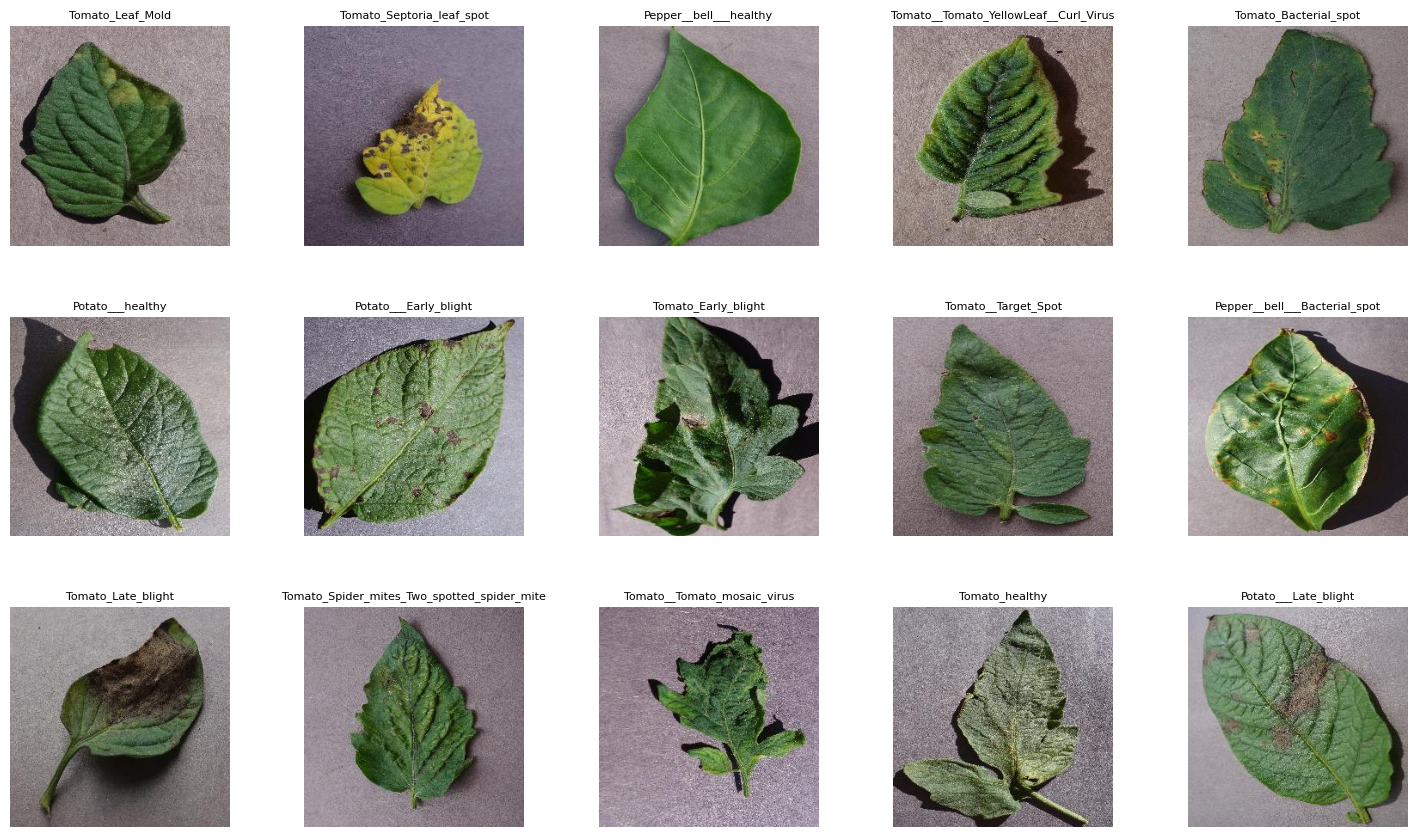

In [27]:
import matplotlib.pyplot as plt

def display_images_from_directories(base_dir, num_cols=5):
    """Displays one image from each subdirectory side by side.

    Args:
      base_dir: The path to the base directory containing subdirectories with images.
      num_cols: The number of columns for the subplot grid.
    """

    dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    num_dirs = len(dirs)

    num_rows = (num_dirs + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
    fig.tight_layout(pad=2.0)

    for i, dir_name in enumerate(dirs):
        dir_path = os.path.join(base_dir, dir_name)
        image_files = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)) and (f.lower().endswith(('.png', '.jpg', '.jpeg')))]
        if image_files:
            image_path = os.path.join(dir_path, image_files[0])
            try:
                img = plt.imread(image_path)
                row = i // num_cols
                col = i % num_cols
                axes[row, col].imshow(img)
                axes[row, col].set_title(dir_name, fontsize=8)
                axes[row, col].axis('off')
            except Exception as e:
                print(f"Error displaying image from {dir_name}: {e}")
        else:
            print(f"No images found in directory: {dir_name}")

    for i in range(num_dirs, num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axes[row, col].axis('off')
    plt.show()

display_images_from_directories('/content/PlantVillage')


In [18]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [19]:
data_dir = '/content/PlantVillage'
img_size = 28
batch_size = 32

In [10]:
IMG_SIZE = 128
BATCH_SIZE = 32

In [20]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    data_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


In [23]:
num_classes = len(train_generator.class_indices)

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(img_size, img_size, 3)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(train_generator, validation_data=val_generator, epochs=20)

Epoch 1/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.3065 - loss: 2.2252 - val_accuracy: 0.5138 - val_loss: 1.6266
Epoch 2/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.5261 - loss: 1.5353 - val_accuracy: 0.5344 - val_loss: 1.4616
Epoch 3/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.5660 - loss: 1.3557 - val_accuracy: 0.6029 - val_loss: 1.3139
Epoch 4/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.6107 - loss: 1.2313 - val_accuracy: 0.6167 - val_loss: 1.2247
Epoch 5/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.6351 - loss: 1.1431 - val_accuracy: 0.6084 - val_loss: 1.2583
Epoch 6/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - accuracy: 0.6583 - loss: 1.0835 - val_accuracy: 0.6225 - val_loss: 1.1931
Epoch 7/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.6780 - loss: 1.0058 - val_accuracy: 0.6599 - val_loss: 1.0886
Epoch 8/20
517/517 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.6857 - loss: 0.9613 - 

In [24]:
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_acc * 100:.2f}%')

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6675 - loss: 1.0777
Validation Accuracy: 67.90%


In [26]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 2352)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 128)                 │         301,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 909,359 (3.47 MB)

 Trainable params: 303,119 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 606,240 (2.31 MB)

In [36]:
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.7800 - loss: 0.6574 - val_accuracy: 0.6999 - val_loss: 0.9281
Epoch 2/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8020 - loss: 0.6014 - val_accuracy: 0.7052 - val_loss: 0.9387
Epoch 3/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.8032 - loss: 0.5917 - val_accuracy: 0.7096 - val_loss: 0.9262
Epoch 4/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.8003 - loss: 0.6032 - val_accuracy: 0.7222 - val_loss: 0.9008
Epoch 5/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.8055 - loss: 0.5828 - val_accuracy: 0.7111 - val_loss: 0.9338
Epoch 6/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.8112 - loss: 0.5644 - val_accuracy: 0.7137 - val_loss: 0.9345
Epoch 7/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step - accuracy: 0.8202 - loss: 0.5550 - val_accuracy: 0.6926 - val_loss: 0.9805
Epoch 8/10
517/517 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.8258 - loss: 0.5358 - 

In [37]:
val_loss, val_acc = model.evaluate(val_generator)
print(f'Validation Accuracy: {val_acc * 100:.2f}%')

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7255 - loss: 0.9089
Validation Accuracy: 72.20%


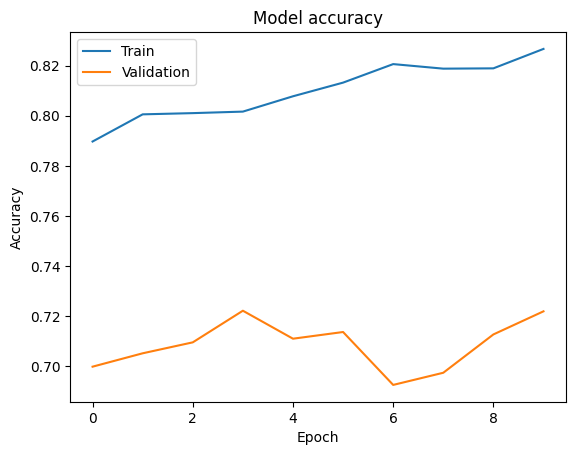

In [41]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

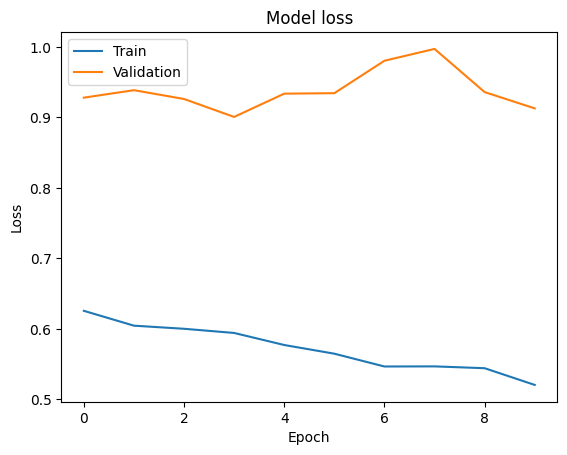

In [42]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━

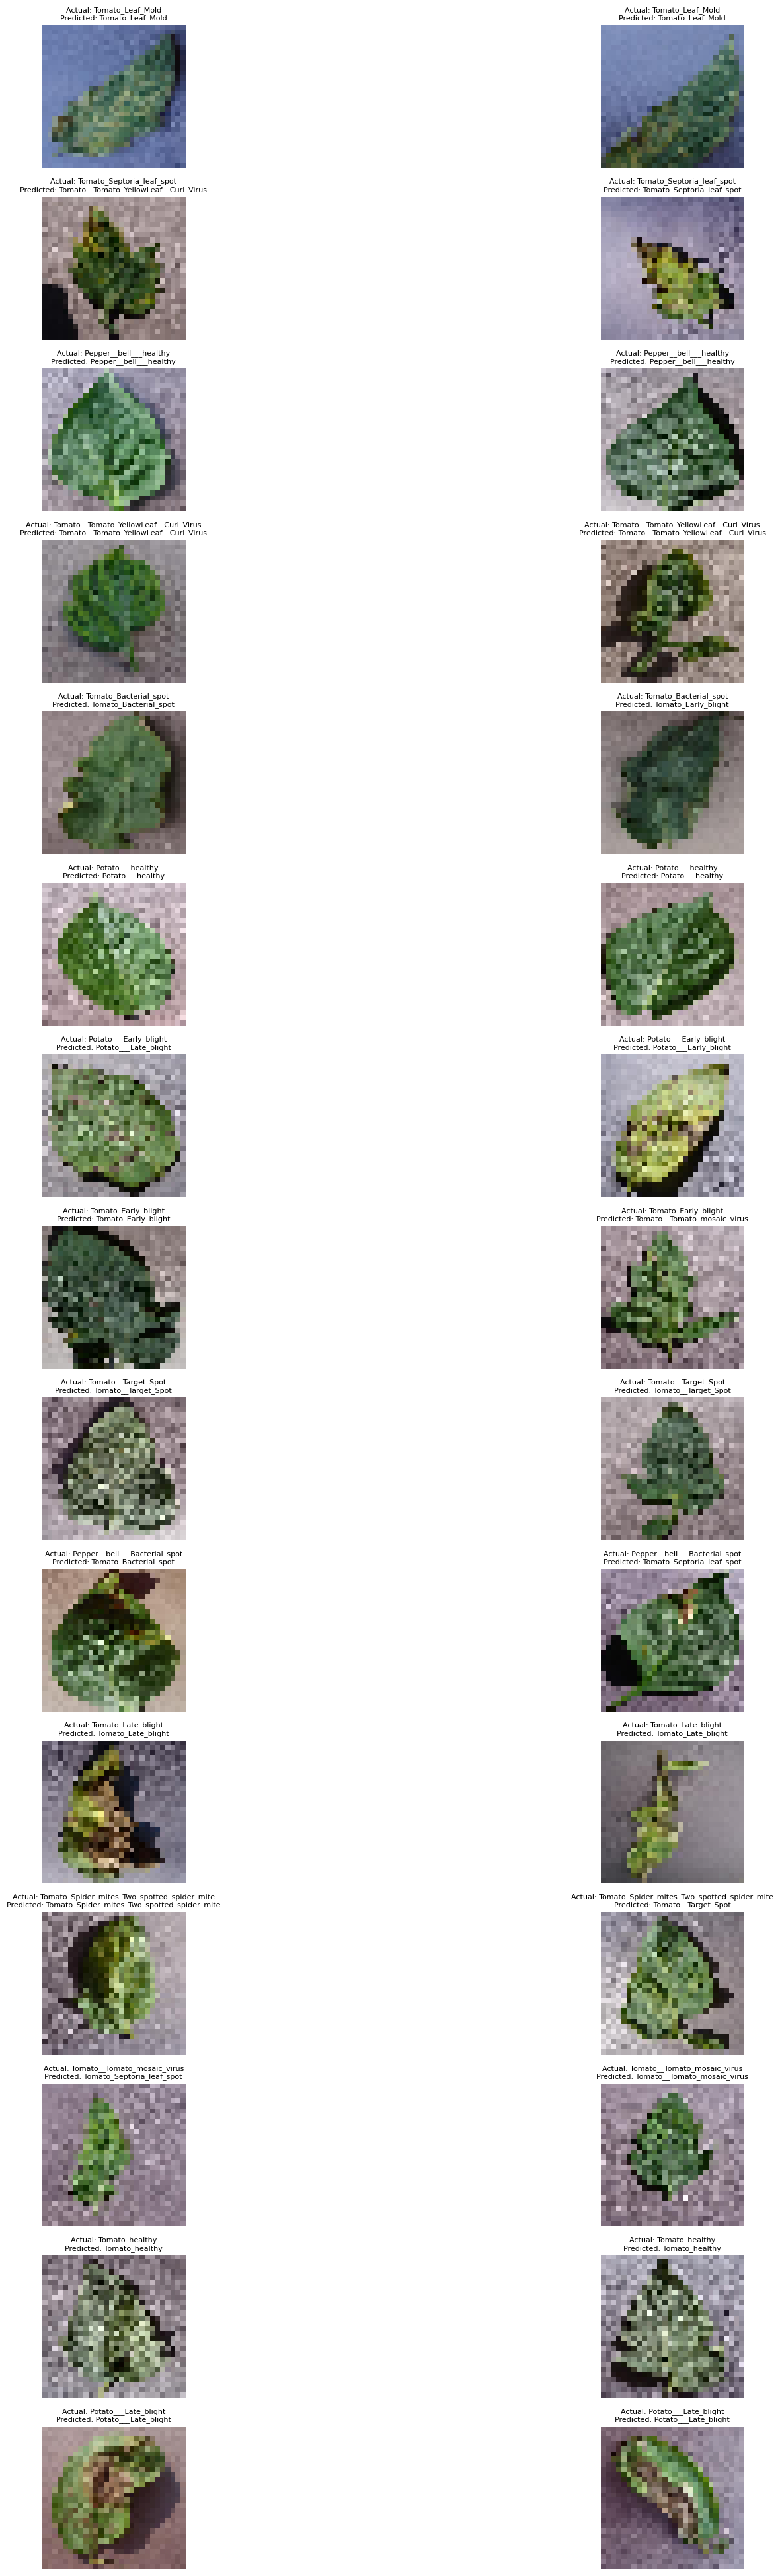

In [50]:
import numpy as np
import random

def predict_and_display_images(model, base_dir, num_images=2):
    dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

    plt.figure(figsize=(20, 50))

    for i, dir_name in enumerate(dirs):
        dir_path = os.path.join(base_dir, dir_name)
        image_files = [f for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)) and (f.lower().endswith(('.png', '.jpg', '.jpeg')))]

        selected_images = random.sample(image_files, min(num_images, len(image_files)))

        for j, image_file in enumerate(selected_images):
            image_path = os.path.join(dir_path, image_file)
            img = keras.preprocessing.image.load_img(image_path, target_size=(img_size, img_size))
            img_array = keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0) / 255.0

            prediction = model.predict(img_array)
            predicted_class_index = np.argmax(prediction)
            predicted_class = list(train_generator.class_indices.keys())[list(train_generator.class_indices.values()).index(predicted_class_index)]

            plt.subplot(len(dirs), num_images, i * num_images + j + 1)
            plt.imshow(img)
            plt.title(f"Actual: {dir_name}\nPredicted: {predicted_class}", fontsize=8)
            plt.axis('off')

    plt.show()

predict_and_display_images(model, '/content/PlantVillage')
